In [1]:
library(ggplot2)
library(readr)
library(tidyverse)
library(lubridate)
library(scales)
library(Cairo)
library(wesanderson)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ stringr   1.5.1
✔ forcats   1.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: 'scales'




The following object is masked from 'package:purrr':

    discard




The following object is masked from 'package:readr':

    col_factor




In [2]:
# Thanks https://stats.andrewheiss.com/misc/gantt.html

permanent_lab_members <- read.delim("lab_members.txt")
#change this to the current date to update all current lab members
date <- "2026-09-28"
permanent_lab_members$End[permanent_lab_members$End=="today"]<-date





In [3]:
#Count number of UG trainees
UGs <- permanent_lab_members[permanent_lab_members$Project == "undergraduate", ]

UGs_count <- UGs %>%
  nrow()
print(UGs_count)

message <- paste("I've worked with", 
                 UGs_count, 
                 "undergraduate trainees since 2019 in my lab at UW. Prior to this I directly supervised 11 undergraduates at UC San Diego (7), UC Berkeley (3), and Tufts University (1)"
                )
print(message)

print(UGs)

[1] 31


[1] "I've worked with 31 undergraduate trainees since 2019 in my lab at UW. Prior to this I directly supervised 11 undergraduates at UC San Diego (7), UC Berkeley (3), and Tufts University (1)"


                    Task       Project      Start        End keep
3         Anthony Garcia undergraduate 2019-10-01 2021-06-16    1
7          Brian Behnken undergraduate 2022-02-01 2023-08-31    1
11         Morgan Alonso undergraduate 2022-09-01 2024-06-01    0
12    Cora Werner Lovell undergraduate 2022-09-01 2024-06-01    0
13           Aster Earls undergraduate 2023-09-01 2025-12-31    0
14             Ty Bryant undergraduate 2023-09-01 2025-03-01    0
15         Nick Peterson undergraduate 2023-09-01 2026-09-28    0
16         Euan McCubbin undergraduate 2024-01-01 2025-06-01    1
19     Ava Kloss-Schmidt undergraduate 2019-10-01 2022-06-01    0
21            August Liu undergraduate 2021-01-06 2021-05-30    0
22        Sanjana Jadhav undergraduate 2021-01-25 2021-06-15    0
23            Sandy Tran undergraduate 2021-03-15 2022-06-01    0
26         Hannah Luskin undergraduate 2021-09-01 2023-06-15    0
27        Karyn Tindbaek undergraduate 2021-09-01 2022-06-01    0
28       C

In [4]:
#Count number of non-UG trainees
nonUGs <- permanent_lab_members[!(permanent_lab_members$Project %in% c("undergraduate", "PI", "rotation student")), ]

nonUGs_count <- nonUGs %>%
  nrow()
print(nonUGs_count)

message2 <- paste("I've worked with", nonUGs_count, "technicians, graduate students, and postdocs since 2019")
print(message2)

print(nonUGs)

[1] 13


[1] "I've worked with 13 technicians, graduate students, and postdocs since 2019"


                        Task               Project      Start        End keep
2             Tonio Chaparro            technician 2019-09-01 2022-06-01    1
4             Anthony Garcia            technician 2021-06-16 2022-09-01    1
5               Simon Snoeck               postdoc 2019-11-01 2023-01-01    1
6  Natalia Guayazan-Palacios      graduate student 2020-01-01 2025-08-31    1
8              Brian Behnken            technician 2023-09-01 2026-09-28    1
9               Ben Sheppard      graduate student 2022-04-01 2026-09-28    1
10             Wesley George            technician 2022-09-01 2023-09-01    1
17             Euan McCubbin            technician 2025-06-01 2026-09-28    1
18             Di 'Woody' Wu               postdoc 2023-10-01 2026-09-28    1
42               Kelsey Wood               postdoc 2024-11-01 2026-01-01    1
46                 Amy Moore      graduate student 2025-01-01 2026-09-28    1
47                   Emma Li high school volunteer 2025-10-01 20

In [5]:
#keep only the rows that don't meet the condition of being an undergraduate or rotation student with an "End" value of "today"
removed_entries <- permanent_lab_members %>%
  filter(keep == 0)

permanent_lab_members <- permanent_lab_members %>%
  filter(keep == 1)


print(permanent_lab_members)


                        Task               Project      Start        End keep
1          Adam Steinbrenner                    PI 2019-08-31 2026-09-28    1
2             Tonio Chaparro            technician 2019-09-01 2022-06-01    1
3             Anthony Garcia         undergraduate 2019-10-01 2021-06-16    1
4             Anthony Garcia            technician 2021-06-16 2022-09-01    1
5               Simon Snoeck               postdoc 2019-11-01 2023-01-01    1
6  Natalia Guayazan-Palacios      graduate student 2020-01-01 2025-08-31    1
7              Brian Behnken         undergraduate 2022-02-01 2023-08-31    1
8              Brian Behnken            technician 2023-09-01 2026-09-28    1
9               Ben Sheppard      graduate student 2022-04-01 2026-09-28    1
10             Wesley George            technician 2022-09-01 2023-09-01    1
11             Euan McCubbin         undergraduate 2024-01-01 2025-06-01    1
12             Euan McCubbin            technician 2025-06-01 20

In [6]:

# Convert data to long for ggplot
permanent_lab_members.long <- permanent_lab_members %>%
  mutate(Start = ymd(Start),
         End = ymd(End)) %>%
  gather(date.type, task.date, -c(Project, Task, keep)) %>%
  group_by(Task) %>%
  mutate(Start_Date = min(task.date)) %>%
  ungroup() %>%
  arrange(Start_Date, date.type, task.date) %>%
  mutate(Task = factor(Task, levels=rev(unique(Task)), ordered=TRUE))

removed_entries <- removed_entries %>%
  mutate(Start = ymd(Start),
         End = ymd(End)) %>%
  gather(date.type, task.date, -c(Project, Task, keep)) %>%
  group_by(Task) %>%
  mutate(Start_Date = min(task.date)) %>%
  ungroup() %>%
  arrange(Start_Date, date.type, task.date) %>%
  mutate(Task = factor(Task, levels=rev(unique(Task)), ordered=TRUE))


# Custom theme for making a clean Gantt chart
theme_gantt <- function(base_size=11, base_family="sans") {
  ret <- theme_bw(base_size, base_family) %+replace%
    theme(panel.background = element_rect(fill="#ffffff", colour=NA),
          axis.title.x=element_text(vjust=-0.2), axis.title.y=element_text(vjust=1.5),
          title=element_text(vjust=1.2, family="Source Sans Pro Semibold"),
          panel.border = element_blank(), axis.line=element_blank(),
          panel.grid.minor=element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.major.x = element_line(size=0.5, colour="grey80"),
          axis.ticks=element_blank(),
          legend.position="bottom",
          legend.box = "vertical",
          legend.box.just = "left",
          legend.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"),
          legend.spacing.x = unit(0.2, 'cm'),
          legend.spacing.y = unit(0.2, 'cm'),
          legend.box.spacing = unit(0.2, 'cm'),
          legend.key.size = unit(0.5, 'lines'),
          legend.text = element_text(size = rel(0.8)),
          axis.title=element_text(size=rel(0.8), family="Source Sans Pro Semibold"),
          strip.text=element_text(size=rel(1), family="Source Sans Pro Semibold"),
          strip.background=element_rect(fill="#ffffff", colour=NA),
          panel.spacing.y=unit(1.5, "lines"),
          legend.key = element_blank())
  
  ret
}
  


In [7]:
# Calculate where to put the dotted lines that show up every three entries
#x.breaks <- seq(length(tasks$Task) + 0.5 - 3, 0, by=-3)
x.breaks <- seq(length(permanent_lab_members$Task) + 0.5, 0, by=-3)


# Named palette so each role keeps its colour regardless of which roles are present
pal <- c("graduate student"      = "#FF0000",
         "PI"                    = "#00A08A",
         "postdoc"               = "#F2AD00",
         "technician"            = "#046C9A",
         "undergraduate"         = "#5BBCD6",
         "high school volunteer" = "#8566AA",
         "rotation student"      = "#FF0000")
print(pal)

     graduate student                    PI               postdoc 
            "#FF0000"             "#00A08A"             "#F2AD00" 
           technician         undergraduate high school volunteer 
            "#046C9A"             "#5BBCD6"             "#8566AA" 
     rotation student 
            "#FF0000" 


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


...

Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


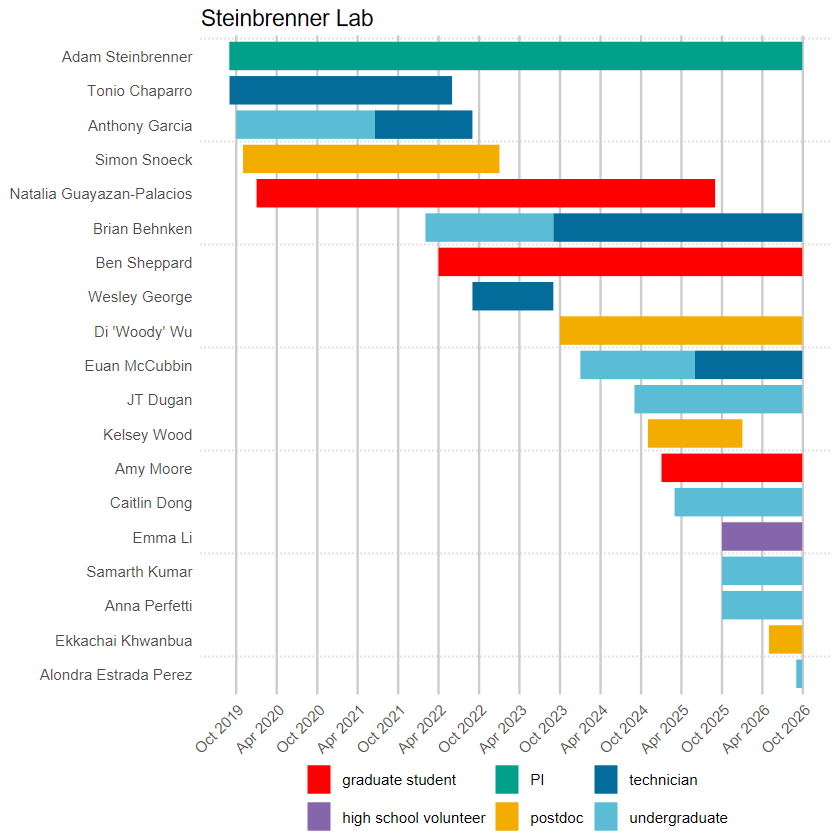

In [8]:
# Build plot
timeline <- ggplot(permanent_lab_members.long, aes(x=Task, y=task.date, colour=Project)) + 
  geom_line(size=6) + 
  #geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted") + 
  guides(colour=guide_legend(title=NULL)) +
  labs(x=NULL, y=NULL) + coord_flip() +
  scale_y_date(date_breaks="6 months", labels=date_format("%b %Y")) +
  theme_gantt() + theme(axis.text.x=element_text(angle=45, hjust=1)) + scale_color_manual(values=pal) +ggtitle("Steinbrenner Lab") +
  #reorder the list according to the input text document
scale_x_discrete(limits = rev(unique(permanent_lab_members.long$Task))) +
  geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted")

timeline

In [9]:
filtered_removed_entries <- removed_entries[removed_entries$date.type == "End", ]
write.csv(filtered_removed_entries, "previous_UG_rotations.csv", row.names=FALSE)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'Source Sans Pro Semibold' not found in PostScript font database"


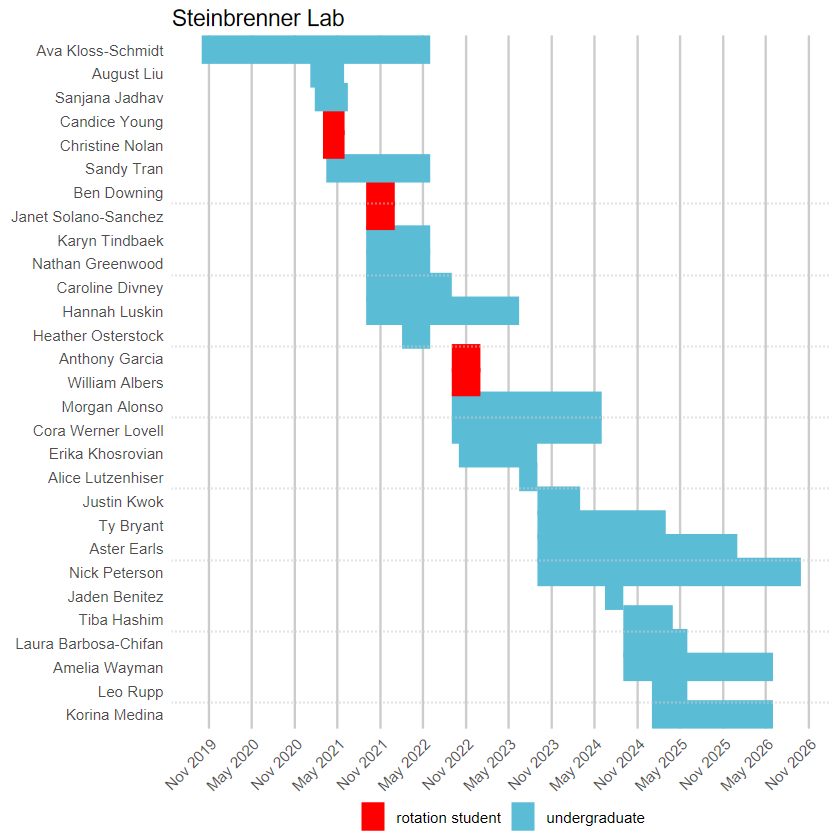

In [10]:
# Build plot
timeline2 <- ggplot(removed_entries, aes(x=Task, y=task.date, colour=Project)) + 
  geom_line(size=6) + 
  #geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted") + 
  guides(colour=guide_legend(title=NULL)) +
  labs(x=NULL, y=NULL) + coord_flip() +
  scale_y_date(date_breaks="6 months", labels=date_format("%b %Y")) +
  theme_gantt() + theme(axis.text.x=element_text(angle=45, hjust=1)) + scale_color_manual(values=pal) +ggtitle("Steinbrenner Lab") +
  #reorder the list according to the input text document
scale_x_discrete(limits = rev(unique(removed_entries$Task))) +
  geom_vline(xintercept=x.breaks, colour="grey80", linetype="dotted")


timeline2

In [11]:
#ggsave("~/08_website/github/steinbrennerlab.github.io/lab_members.png",width=6,height=8,timeline)
ggsave("lab_members.png",width=6,height=5,timeline)
ggsave("previous_UG_rotations.png",width=6,height=5,timeline2)